# LendingGuard: Enterprise Credit Risk Assessment System
**End-to-End Machine Learning untuk Memprediksi Risiko Gagal Bayar (Default)**

### Business Objective
Non-Performing Loan (NPL) atau kredit macet adalah risiko terbesar bagi institusi finansial. Proyek ini bertujuan untuk membangun model Machine Learning prediktif yang mampu:
1. **Mengidentifikasi** calon nasabah yang berpotensi gagal bayar sejak hari pertama pengajuan.
2. **Menekan kerugian finansial** bank akibat kredit macet.
3. **Memberikan alasan transparan (Explainability)** mengapa seorang nasabah ditolak, sesuai dengan regulasi perbankan.

# Import Libraries

In [1]:
# Package untuk analisis dan manipulasi data
import pandas as pd
import numpy as np

# Package untuk visualisasi data
import matplotlib.pyplot as plt
import seaborn as sns

# Package Statistik
from scipy import stats
from scipy.stats import kendalltau, pearsonr
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Package untuk Machine Learning (Model & Evaluasi)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, classification_report
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Package untuk Machine Learning (Preprocessing & Pipeline)
from sklearn.model_selection import train_test_split, GridSearchCV
from feature_engine.outliers import Winsorizer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import joblib
from sklearn.impute import SimpleImputer


# Pengaturan Pandas agar semua kolom dan baris terlihat jelas saat di-print
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Pengaturan tema visualisasi agar lebih profesional (cocok untuk disalin ke PPT)
sns.set_theme(style="whitegrid", palette="muted")

# Data Loading

In [2]:
# load data mentah

df = pd.read_csv('loan_data_2007_2014.csv', index_col=0, low_memory=False)

In [3]:
# menampilkan 10 data teratas dan terbawah

print('10 data teratas :')
display(df.head(10))

print(" ")
print('10 data terbawah :')
display(df.tail(10))

10 data teratas :


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_il_6m,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
0,1077501,1296599,5000,5000,4975.0,36 months,10.65,162.87,B,B2,NaN,10+ years,RENT,24000.0,Verified,Dec-11,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/22/11 > I need to upgra...,credit_card,Computer,860xx,AZ,27.65,0.0,Jan-85,1.0,NaN,NaN,3.0,0.0,13648,83.7,9.0,f,0.00,0.00,5861.071414,5831.78,5000.00,861.07,0.00,0.00,0.00,Jan-15,171.62,NaN,Jan-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1077430,1314167,2500,2500,2500.0,60 months,15.27,59.83,C,C4,Ryder,< 1 year,RENT,30000.0,Source Verified,Dec-11,Charged Off,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/22/11 > I plan to use t...,car,bike,309xx,GA,1.00,0.0,Apr-99,5.0,NaN,NaN,3.0,0.0,1687,9.4,4.0,f,0.00,0.00,1008.710000,1008.71,456.46,435.17,0.00,117.08,1.11,Apr-13,119.66,NaN,Sep-13,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1077175,1313524,2400,2400,2400.0,36 months,15.96,84.33,C,C5,NaN,10+ years,RENT,12252.0,Not Verified,Dec-11,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,NaN,small_business,real estate business,606xx,IL,8.72,0.0,Nov-01,2.0,NaN,NaN,2.0,0.0,2956,98.5,10.0,f,0.00,0.00,3003.653644,3003.65,2400.00,603.65,0.00,0.00,0.00,Jun-14,649.91,NaN,Jan-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1076863,1277178,10000,10000,10000.0,36 months,13.49,339.31,C,C1,AIR RESOURCES BOARD,10+ years,RENT,49200.0,Source Verified,Dec-11,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/21/11 > to pay for prop...,other,personel,917xx,CA,20.00,0.0,Feb-96,1.0,35.0,NaN,10.0,0.0,5598,21.0,37.0,f,0.00,0.00,12226.302210,12226.30,10000.00,2209.33,16.97,0.00,0.00,Jan-15,357.48,NaN,Jan-15,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1075358,1311748,3000,3000,3000.0,60 months,12.69,67.79,B,B5,University Medical Group,1 year,RENT,80000.0,Source Verified,Dec-11,Current,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/21/11 > I plan on combi...,other,Personal,972xx,OR,17.94,0.0,Jan-96,0.0,38.0,NaN,15.0,0.0,27783,53.9,38.0,f,766.90,766.90,3242.170000,3242.17,2233.10,1009.07,0.00,0.00,0.00,Jan-16,67.79,Feb-16,Jan-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,1075269,1311441,5000,5000,5000.0,36 months,7.90,156.46,A,A4,Veolia Transportaton,3 years,RENT,36000.0,Source Verified,Dec-11,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,NaN,wedding,My wedding loan I promise to pay back,852xx,AZ,11.20,0.0,Nov-04,3.0,NaN,NaN,9.0,0.0,7963,28.3,12.0,f,0.00,0.00,5631.377753,5631.38,5000.00,631.38,0.00,0.00,0.00,Jan-15,161.03,NaN,Sep-15,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,1069639,1304742,7000,7000,7000.0,60 months,15.96,170.08,C,C5,Southern Star Photo

 
10 data terbawah :


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_il_6m,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
466275,9715141,11567259,6000,6000,6000.0,36 months,15.61,209.79,C,C4,manager,7 years,RENT,27000.0,Verified,Jan-14,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,NaN,credit_card,Credit card refinancing,913xx,CA,26.13,0.0,Nov-93,3.0,NaN,106.0,8.0,1.0,6025,57.4,16.0,f,0.00,0.00,6865.500000,6865.50,5999.95,865.55,0.0,0.0,0.000,Mar-15,126.16,NaN,Jan-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,0.0,259863.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10500.0,NaN,NaN,NaN
466276,9695736,11547808,8525,8525,8525.0,60 months,18.25,217.65,D,D3,MANAGER,5 years,MORTGAGE,37536.0,Verified,Jan-14,Charged Off,n,https://www.lendingclub.com/browse/loanDetail....,NaN,medical,Medical expenses,011xx,MA,12.28,4.0,Nov-94,0.0,3.0,NaN,12.0,0.0,5318,10.7,26.0,f,0.00,0.00,2029.930000,2029.93,360.08,510.45,0.0,1159.4,11.594,May-14,217.65,NaN,Oct-14,0.0,4.0,1,INDIVIDUAL,NaN,NaN,NaN,0.0,0.0,116995.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,49800.0,NaN,NaN,NaN
466277,9007579,10799568,18000,18000,17975.0,36 months,7.90,563.23,A,A4,sales rep,3 years,RENT,90000.0,Verified,Jan-14,Charged Off,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/09/13 > consolidate all...,debt_consolidation,my loan,212xx,MD,10.33,1.0,Jul-98,0.0,14.0,NaN,16.0,0.0,8224,16.3,33.0,f,0.00,0.00,5631.670000,5623.85,4580.89,1050.78,0.0,0.0,0.000,Nov-14,563.23,NaN,Oct-14,0.0,14.0,1,INDIVIDUAL,NaN,NaN,NaN,0.0,0.0,42592.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,50300.0,NaN,NaN,NaN
466278,9745590,11597671,10000,10000,10000.0,36 months,18.25,362.78,D,D3,MecÃ¡nica,10+ years,RENT,42000.0,Source Verified,Jan-14,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,NaN,vacation,Vacation,201xx,VA,11.57,0.0,Jun-02,0.0,29.0,NaN,9.0,0.0,3196,28.8,24.0,f,0.00,0.00,12394.165200,12394.17,10000.00,2394.17,0.0,0.0,0.000,Sep-15,5501.60,NaN,Jan-16,0.0,32.0,1,INDIVIDUAL,NaN,NaN,NaN,0.0,0.0,10170.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11100.0,NaN,NaN,NaN
466279,9745484,11597572,15000,15000,15000.0,36 months,13.53,509.25,B,B5,Director of Operations,4 years,RENT,66000.0,Source Verified,Jan-14,Current,n,https://www.lendingclub.com/browse/loanDetail....,NaN,credit_card,Credit card refinancing,208xx,MD,16.22,0.0,Aug-99,0.0,NaN,NaN,8.0,0.0,16901,96.0,20.0,w,5685.63,5685.63,12222.000000,12222.00,9314.37,2907.63,0.0,0.0,0.000,Jan-16,509.25,Feb-16,Jan-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,0.0,20140.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17600.0,NaN,NaN,NaN
466280,8598660,1440975,18400,18400,18400.0,60 months,14.47,432.64,C,C2,Financial Advisor,4 years,MORTGAGE,110000.0,Source Verified,Jan-14,Current,n,https://www.lendingclub.com/browse/loanDetail....,NaN,debt_consolidation,Debt consolidation,773xx,TX,19.85,0.0,Apr-03,2.0,NaN,NaN,18.0,0.0,23208,77.6,36.0,w,12574.00,12574.00,10383.360000,10383.36,5826.00,4557.36,0.0,0.0,0.000,Jan-16,432.64,Feb-16,Jan-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,0.0,294998.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29900.0,NaN,NaN,NaN
466281,9684700,11536848,22000,22000,22000.0,60 months,19.97,582

In [4]:
# Ringkasan Struktur Dataset

df.shape

(466285, 74)

dataset memiliki 466,285 Baris dan 74 kolom atribut.

In [5]:
# Identifikasi Tipe Data dan Kelengkapan

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 466285 entries, 0 to 466284
Data columns (total 74 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           466285 non-null  int64  
 1   member_id                    466285 non-null  int64  
 2   loan_amnt                    466285 non-null  int64  
 3   funded_amnt                  466285 non-null  int64  
 4   funded_amnt_inv              466285 non-null  float64
 5   term                         466285 non-null  object 
 6   int_rate                     466285 non-null  float64
 7   installment                  466285 non-null  float64
 8   grade                        466285 non-null  object 
 9   sub_grade                    466285 non-null  object 
 10  emp_title                    438697 non-null  object 
 11  emp_length                   445277 non-null  object 
 12  home_ownership               466285 non-null  object 
 13  annu

pengamatan awal :

- Kalau di lihat dari banyak nya baris data, ada beberapa kolom yang sama sekali tidak berisi nilai value (keterangan nya adalah 0 non-null), kolom-kolom itu akan di lihat kenapa bisa kosong dan bisa menjadi pertimbangan untuk di drop agar mengurangi dimensi kolom dan akurasi prediksi model.

- Mayoritas data berupa numerik, 46 kolom bertipe float dan 6 kolom nya bertipe data int, jadi total 52 kolom.

- kolom kategorik berjumlah 22 kolom dengan tipe data object, kalau di lihat dari data yang di tampilkan, ada kolom yang hanya memiliki 1 nilai unik saja.

# **Data Understanding**

In [6]:
# Statistik Deskriptif (Numerikal)

display(df.describe().round(2))

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,dti,delinq_2yrs,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_amnt,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_il_6m,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
count,466285.00,466285.00,466285.00,466285.00,466285.00,466285.00,466285.00,466281.00,466285.00,466256.00,466256.00,215934.00,62638.00,466256.00,466256.00,466285.00,465945.00,466256.00,466285.00,466285.00,466285.00,466285.00,466285.00,466285.00,466285.00,466285.00,466285.00,466285.00,466140.00,98974.00,466285.0,0.0,0.0,0.0,466256.00,396009.00,396009.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,396009.00,0.0,0.0,0.0
mean,13079729.91,14597660.62,14317.28,14291.80,14222.33,13.83,432.06,73277.38,17.22,0.28,0.80,34.10,74.31,11.19,0.16,16230.20,56.18,25.06,4410.06,4408.45,11540.69,11469.89,8866.01,2588.68,0.65,85.34,8.96,3123.91,0.01,42.85,1.0,NaN,NaN,NaN,0.00,191.91,138801.71,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30379.09,NaN,NaN,NaN
std,10893711.62,11682367.44,8286.51,8274.37,8297.64,4.36,243.49,54963.57,7.85,0.80,1.09,21.78,30.36,4.99,0.51,20676.25,23.73,11.60,6355.08,6353.20,8265.63,8254.16,7031.69,2483.81,5.27,552.22,85.49,5554.74,0.11,21.66,0.0,NaN,NaN,NaN,0.07,14630.21,152114.66,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37247.13,NaN,NaN,NaN
min,54734.00,70473.00,500.00,500.00,0.00,5.42,15.67,1896.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.0,NaN,NaN,NaN,0.00,0.00,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN,NaN
25%,3639987.00,4379705.00,8000.00,8000.00,8000.00,10.99,256.69,45000.00,11.36,0.00,0.00,16.00,53.00,8.00,0.00,6413.00,39.20,17.00,0.00,0.00,5552.13,5499.25,3708.56,957.28,0.00,0.00,0.00,312.62,0.00,26.00,1.0,NaN,NaN,NaN,0.00,0.00,28618.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13500.00,NaN,NaN,NaN
50%,10107897.00,11941075.00,12000.00,12000.00,12000.00,13.66,379.89,63000.00,16.87,0.00,0.00,31.00,76.00,10.00,0.00,11764.00,57.60,23.00,441.47,441.38,9419.25,9355.43,6817.76,1818.88,0.00,0.00,0.00,545.96,0.00,42.00,1.0,NaN,NaN,NaN,0.00,0.00,81539.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22800.00,NaN,NaN,NaN
75%,20731209.00,23001541.00,20000.00,20000.00,19950.00,16.49,566.58,88960.00,22.78,0.00,1.00,49.00,102.00,14.00,0.00,20333.00,74.70,32.00,7341.65,7338.39,15308.16,15231.31,12000.00,3304.53,0.00,0.00,0.00,3187.51,0.00,59.00,1.0,NaN,NaN,NaN,0.00,0.00,208953.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37900.00,NaN,NaN,NaN
max,38098114.00,40860827.00,35000.00,35000.00,35000.00,26.06,1409.99,7500000.00,39.99,29.00,33.00,188.00,129.00,84.00,63.00,2568995.00,892.30,156.00,32160.38,32160.38,57777.58,57777.58,35000.03,24205.62,358.68,33520.27,7002.19,36234.44,20.00,188.00,1.0,NaN,NaN,NaN,5.00,9152545.00,8000078.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9999999.00,NaN,NaN,NaN


- di lihat dari pendapatan tahunan (`annual_inc`) : Rata-rata pendapatan pelamar adalah 73.277, dan nilai mediannya adalah 63.000 dan 75% pelamar gajinya di bawah 88.960. tetapi, nilai maksimumnya mencapai 7.500.000 nilai ini sangat extreme dan outlier sehingga distribusi nilai skewed nya akan condong ke kanan, hal ini akan merusak model nanti nya dengan begitu akan di lakukan beberapa cara agar memangkas nya.

- sementara itu nilai rasio utang terhadap pendapatan (`dti`) : rata-rata nya di angka 17,22% dan nilai maksimalnya 39,99% ini adalah angka yang normal dan bagus, kalau di lihat kenapa nilai maksimal nya mentok di angka segitu, saya berasumsi bahwa Credit Policy dari perusahaan akan menolak pelamar yang rasio utangnya di atas 40%, yang artinya nilai tersebut adalah batas aman industri.

- kita lihat juga karakteristis dari peminjam seperti Utilisasi Kartu Kredit (`revol_util`) : bisa di lihat kalau rata-rata pelamar itu menghabiskan 56% limit kartu kredit nya, sedangkan ketika lihat nilai maksimal nya mencapai 892,3%, nilai ini sangat tidak masuk akal dan tidak normal, kemungkinan peminjam menggunakan limit hingga 8x lipat dari batasnya. menandakan pelamar mengalami masalah finansial di mana kartu kreditnya overlimit karena denda yang menumpuk, ini berindikasi kuat bad loan.

In [7]:
#cek jumlah data yang duplikat

df.duplicated().sum()
print(f"terdapat {df.duplicated().sum()} data yang terindikasi duplicate")

terdapat 0 data yang terindikasi duplicate


semua informasi pada kolom tidak ada yang sama, ini bagus pada saat pelatihan model nanti.

# **Data Preparation**

## Data Cleansing

### Drop Columns

1. Data Leakage (Kebocoran Data)

*Machine Learning* untuk persetujuan kredit harus memprediksi risiko berdasarkan informasi *saat hari pengajuan*. Kolom-kolom di bawah ini merekam aktivitas/pembayaran **setelah** pinjaman disetujui dan berjalan. Jika dimasukkan, model akan "menyontek" apa yang terjadi pada masa depan dan tidak akan valid untuk pelamar baru.

  * **`funded_amnt`, `funded_amnt_inv`**: Nominal yang akhirnya didanai oleh investor (sudah diwakili oleh `loan_amnt` yang merupakan nominal pengajuan awal).
  * **`issue_d`**: Bulan dan tahun pinjaman didanai/dicairkan.
  * **`out_prncp`, `out_prncp_inv`**: Sisa pokok utang peminjam saat ini.
  * **`total_pymnt`, `total_pymnt_inv`, `total_rec_prncp`, `total_rec_int`, `total_rec_late_fee`**: Total uang, rincian pokok, bunga, dan denda yang sudah dibayarkan nasabah hingga hari ini.
  * **`last_pymnt_amnt`, `last_pymnt_d`, `next_pymnt_d`**: Nominal dan tanggal pembayaran cicilan terakhir serta jadwal selanjutnya.
  * **`recoveries`, `collection_recovery_fee`**: Biaya penagihan oleh *Debt Collector* (kolom ini baru terisi jika nasabah sudah terbukti macet total).
  * **`last_credit_pull_d`**: Tanggal terakhir biro kredit menarik data nasabah setelah pinjaman berjalan.

2. Identifier dan Free Text (Kardinalitas Tinggi / Noise)

Kolom ini berisi ID unik sistem atau teks bebas dari nasabah, Kolom ini tidak memiliki pola matematis yang bisa dipelajari oleh model dan hanya akan menjadi *noise* (sampah).
* **`Unnamed: 0`, `id`, `member_id`**: Nomor urut baris dan nomor identitas nasabah di sistem. 
* **`url`**: Tautan halaman website pinjaman nasabah.
* **`emp_title`**: Nama pekerjaan/jabatan yang diketik manual (sangat banyak variasi penulisan untuk profesi yang sama).
* **`title`**: Judul pinjaman yang ditulis bebas oleh nasabah.
* **`desc`**: Teks panjang/paragraf berisi curhatan alasan nasabah untuk meminjam uang.

3. Data Redundan dan Zero Variance (Konstan)

Kolom yang informasinya sudah diwakili oleh kolom lain yang lebih baik, atau kolom yang seluruh isinya hanya satu nilai (konstan) sehingga mesin tidak bisa belajar membedakan nasabah.

* **`zip_code`**: 3 digit kode pos (redudan dan variasi terlalu banyak, saya akan gunakan `addr_state` untuk geografi).
* **`sub_grade`**: Rincian kelas risiko (A1, A2, dst). Dihapus untuk menghindari *overfitting* karena sudah menggunakan kolom `grade` (A, B, C).
* **`earliest_cr_line`**: Format data tanggal (bulan/tahun). Dihapus di *baseline model* untuk menghindari error tipe data.
* **`policy_code`**: Hanya berisi satu angka konstan ("1") untuk seluruh baris data.
* **`application_type`**: Hanya berisi nilai "INDIVIDUAL" untuk seluruh baris data.
* **`pymnt_plan`**: Rencana pembayaran yang hampir seluruh barisnya berisi nilai "n" (no).

4. Data Kosong 100% (Legacy Data dan Tipe Aplikasi)

kolom-kolom ini sama sekali tidak memiliki nilai value dan tidak mungkin bisa diimputasi karena akan membuat data menjadi bias dan model tidak akan belajar apapun dengan data yang kosong.

* **Kolom "Joint Application"**: `annual_inc_joint`, `dti_joint`, `verification_status_joint` (Kosong karena seluruh data ini adalah tipe individual, tidak ada pinjaman suami-istri).
* **Kolom "New Credit Metrics"**: `open_acc_6m`, `open_il_6m`, `open_il_12m`, `open_il_24m`, `mths_since_rcnt_il`, `total_bal_il`, `il_util`, `open_rv_12m`, `open_rv_24m`, `max_bal_bc`, `all_util`, `inq_fi`, `total_cu_tl`, `inq_last_12m` (kosong karena metrik biro kredit ini belum di kumpulkan oleh platform pada tahun dataset ini diambil).

5. Data Kosong yang Ekstrem (> 50%)
kolom yang memiliki nilai kosong hampir di atas 50% kalau di lakukan imputasi ( mengisi nilai nya dengan rata-rata) juga harus didrop karena akan berpotensi menciptakan informasi dan data palsu yang akan merusak akurasi model nantinya.

* **`mths_since_last_delinq`**: Jumlah bulan sejak terakhir menunggak. (Kosong karena mayoritas nasabah tidak pernah menunggak).
* **`mths_since_last_record`**: Jumlah bulan sejak punya catatan publik buruk. (Kosong karena mayoritas nasabah tidak pernah bangkrut/punya kasus hukum).
* **`mths_since_last_major_derog`**: Jumlah bulan sejak penilaian kredit turun drastis.

sebelumnya sudah diidentifikasi kolom-kolom yang tidak memiliki nilai value dan juga kolom yang berpotensi data leakage, saya akan mengeliminasi kolom-kolom tersebut sebelum masuk ke EDA, ini adalah tahap awal, karena nanti di feature selection akan di seleksi lagi kolom-kolom yang cocok untuk pemodelan.

In [8]:
print(df['issue_d'])

0         Dec-11
1         Dec-11
2         Dec-11
3         Dec-11
4         Dec-11
           ...  
466280    Jan-14
466281    Jan-14
466282    Jan-14
466283    Jan-14
466284    Jan-14
Name: issue_d, Length: 466285, dtype: object


In [9]:
print(df['earliest_cr_line'])

0         Jan-85
1         Apr-99
2         Nov-01
3         Feb-96
4         Jan-96
           ...  
466280    Apr-03
466281    Jun-97
466282    Dec-01
466283    Feb-03
466284    Feb-00
Name: earliest_cr_line, Length: 466285, dtype: object


In [10]:

# 'issue_d', 'earliest_cr_line' dua kolom ini belum tau kenapa tidak di drop

cols_to_drop = [
    # Identitas & Teks Bebas (Noise yang merusak memori komputasi)
    'id', 'member_id', 'url', 'desc', 'emp_title', 'title', 'zip_code', 
    
    # DATA LEAKAGE (Variabel masa depan yang haram dimasukkan ke model)
    'funded_amnt', 'funded_amnt_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 
    'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 
    'last_pymnt_amnt', 'last_pymnt_d', 'next_pymnt_d', 'out_prncp', 'out_prncp_inv', 
    'last_credit_pull_d',
    
    # Missing Value Ekstrem (>60%) dan Fitur Joint (Pinjaman gabungan yang tidak relevan)
    'inq_last_12m', 'verification_status_joint', 'open_acc_6m', 'open_il_6m', 
    'open_il_12m', 'open_il_24m', 'mths_since_rcnt_il', 'dti_joint', 
    'total_bal_il', 'annual_inc_joint', 'il_util', 'open_rv_12m', 
    'open_rv_24m', 'max_bal_bc', 'all_util', 'inq_fi', 'total_cu_tl', 
    'mths_since_last_record', 'mths_since_last_major_derog', 'mths_since_last_delinq',
    
    # Zero Variance / Fitur Redundan (Isinya kembar atau sama semua)
    'policy_code', 'application_type', 'pymnt_plan', 'sub_grade',
]

# Pastikan hanya menghapus kolom yang memang ada di dalam dataframe
actual_cols_to_drop = [col for col in cols_to_drop if col in df.columns]
df = df.drop(columns=actual_cols_to_drop)

In [11]:
# Cek sisa missing value di dataset yang sudah di-drop
sisa_missing = df.isnull().sum()
sisa_missing = sisa_missing[sisa_missing > 0].sort_values(ascending=False)

# Tampilkan dalam bentuk persentase
print("--- SISA KOLOM DENGAN MISSING VALUE ---")
print((sisa_missing / len(df)) * 100)

--- SISA KOLOM DENGAN MISSING VALUE ---
tot_coll_amt                  15.071469
tot_cur_bal                   15.071469
total_rev_hi_lim              15.071469
emp_length                     4.505399
revol_util                     0.072917
collections_12_mths_ex_med     0.031097
delinq_2yrs                    0.006219
earliest_cr_line               0.006219
inq_last_6mths                 0.006219
open_acc                       0.006219
pub_rec                        0.006219
total_acc                      0.006219
acc_now_delinq                 0.006219
annual_inc                     0.000858
dtype: float64


In [12]:
nilai_unik = df['issue_d'].unique()

print(nilai_unik)
# Output: ['Apel' 'Jeruk' 'Mangga']

['Dec-11' 'Nov-11' 'Oct-11' 'Sep-11' 'Aug-11' 'Jul-11' 'Jun-11' 'May-11'
 'Apr-11' 'Mar-11' 'Feb-11' 'Jan-11' 'Dec-10' 'Nov-10' 'Oct-10' 'Sep-10'
 'Aug-10' 'Jul-10' 'Jun-10' 'May-10' 'Apr-10' 'Mar-10' 'Feb-10' 'Jan-10'
 'Dec-09' 'Nov-09' 'Oct-09' 'Sep-09' 'Aug-09' 'Jul-09' 'Jun-09' 'May-09'
 'Apr-09' 'Mar-09' 'Feb-09' 'Jan-09' 'Dec-08' 'Nov-08' 'Oct-08' 'Sep-08'
 'Aug-08' 'Jul-08' 'Jun-08' 'May-08' 'Apr-08' 'Mar-08' 'Feb-08' 'Jan-08'
 'Dec-07' 'Nov-07' 'Oct-07' 'Sep-07' 'Aug-07' 'Jul-07' 'Jun-07' 'Dec-13'
 'Nov-13' 'Oct-13' 'Sep-13' 'Aug-13' 'Jul-13' 'Jun-13' 'May-13' 'Apr-13'
 'Mar-13' 'Feb-13' 'Jan-13' 'Dec-12' 'Nov-12' 'Oct-12' 'Sep-12' 'Aug-12'
 'Jul-12' 'Jun-12' 'May-12' 'Apr-12' 'Mar-12' 'Feb-12' 'Jan-12' 'Dec-14'
 'Nov-14' 'Oct-14' 'Sep-14' 'Aug-14' 'Jul-14' 'Jun-14' 'May-14' 'Apr-14'
 'Mar-14' 'Feb-14' 'Jan-14']


### Keeping columns

kolom-kolom yang akan di gunakan ini akan menjadi profil resiko nasabah saat mengajukan pinjaman, sehingga sangat valid dan bagus  untuk training model nanti nya.

kolom-kolom yang di gunakan ini berisi informasi Pre_Origination (data yang sudah di ketahui oleh pihak perusahaan saat nasabah pertama kali mengisi formulir pengajuan pinjaman) untuk memprediksi profil risiko nasabah.

1. kolom target :
`loan_status`: kolom ini akan menjadi target untuk model training, saya akan menggunakan nya terlebih dahulu untuk kebutuhan eksplorasi data, setelah itu akan mengubah nya menjadi kolom baru (misal credit_risk: 1 = Lancar, 0 = Macet). Setelah kolom credit_risk terbentuk, barulah loan_status ini di-drop. 

2. Karakteristik Pinjaman yang Diajukan (Beban Pinjaman) :
* `loan_amnt`: Jumlah pinjaman yang diminta. (Makin besar, risiko makin tinggi).
* `term`: Tenor cicilan (36 atau 60 bulan).
* `int_rate`: Suku bunga pinjaman.
* `installment`: Beban cicilan per bulan.
* `grade & sub_grade`: Penilaian risiko internal awal perusahaan.
* `purpose`: Tujuan pinjaman (untuk nikah, modal usaha, atau bayar utang kartu kredit punya profil risiko yang beda-beda).

3. Kapasitas Peminjam (Profil Demografi nasabah & Finansial) :
* `annual_inc`: pendapatan tahunan nasabah yang di laporkan sendiri (semakin tinggi, semakin mampu bayar).
* `emp_length`: Lama bekerja (menunjukkan kestabilan finansial nasabah).
* `home_ownership`: Status kepemilikan rumah (Milik sendiri/KPR biasanya lebih stabil dari sewa).
* `verification_status`: Apakah gajinya sudah diverifikasi keasliannya atau belum.
* `addr_state`: Domisili peminjam.

4. Karakter & Sejarah Kredit Masa Lalu (Credit History) :
* `dti` (Debt-to-Income) : ration dari total cicilan utang bulanan peminjam(di luar KPR) dibagi dengan pendapatan bulanan. (DTI tinggi = gaji sudah habis untuk bayar utang lain).
* `revol_util`: Persentase pemakaian limit kartu kredit. Kalau sering dipakai mentok, berarti nasabah kurang cash.
* `delinq_2yrs`: Berapa kali nunggak dalam 2 tahun terakhir.
* `inq_last_6mths`: Berapa kali nasabah ini cari-cari pinjaman di bank lain dalam 6 bulan terakhir.
* `open_acc & total_acc`: Jumlah fasilitas kredit yang sedang berjalan dan yang pernah dimiliki.
* `pub_rec`: Rekam jejak kebangkrutan/masalah hukum publik.
* `earliest_cr_line`: Kapan pertama kali punya riwayat kredit. (Catatan: ini format tanggal, nanti saat Feature Engineering bisa diubah jadi numerik "Lama_Bulan_Sejak_Kredit_Pertama").
* `tot_coll_amt, tot_cur_bal`, total_rev_hi_lim: Kolom tambahan ini isinya sekitar 396 ribu (cukup lengkap). Berguna untuk melihat total seluruh utang dan limit nasabah saat ini. Nilai kosongnya (sekitar 15%) bisa kita imputasi dengan Median nanti.

## Data Standardization & Formatting

In [13]:
if 'issue_d' in df.columns and 'earliest_cr_line' in df.columns:
    # Menambahkan format='%b-%y' agar Pandas membaca format "Dec-11" dengan akurat
    df['issue_d_dt'] = pd.to_datetime(df['issue_d'], format='%b-%y')
    df['earliest_cr_line_dt'] = pd.to_datetime(df['earliest_cr_line'], format='%b-%y')
    
    # Cari tahu tahun transaksi paling akhir di dataset ini (Dalam kasus ini pasti 2014)
    max_issue_year = df['issue_d_dt'].dt.year.max()
    
    def fix_century_bug(dt):
        if pd.isna(dt):
            return dt
        # Jika tahun kredit pertama > tahun peminjaman terakhir bank (2014),
        # maka PASTI itu adalah tahun 19XX yang salah dibaca jadi 20XX
        if dt.year > max_issue_year:
            return dt.replace(year=dt.year - 100)
        return dt
        
    df['earliest_cr_line_dt'] = df['earliest_cr_line_dt'].apply(fix_century_bug)
    
    # Mengubah format tanggal menjadi angka "Umur Kredit" dalam satuan bulan
    df['mths_since_earliest_cr'] = (
        (df['issue_d_dt'].dt.year - df['earliest_cr_line_dt'].dt.year) * 12 +
        (df['issue_d_dt'].dt.month - df['earliest_cr_line_dt'].dt.month)
    )
    
    # SANITY CHECK TAMBAHAN UNTUK KEAMANAN (Mencegah nilai negatif)
    # Jika masih ada nilai < 0 karena anomali data, kita set menjadi 0
    df['mths_since_earliest_cr'] = df['mths_since_earliest_cr'].apply(lambda x: max(0, x))
    
    # Setelah saripatinya diambil, buang kolom tanggal mentahnya
    df = df.drop(columns=['issue_d', 'earliest_cr_line', 'issue_d_dt', 'earliest_cr_line_dt'])

### menentukan kolom target

sebelum melatih model dan mengeksplorasi data, terlebih dahulu tentukan kolom yang akan menjadi target, karena kalau salah memilih target, model yang di bangun nanti nya akan tidak berguna.

dalam task ini, perusahaan ingin tahu "apakah calon nasabah ini akan gagal bayar(macet) atau lancar?", jadi yang di butuhkan adalah kolom yang menyimpan berupa rekam jejak akhir pembayaran nasabah pada masa lalu, dalam task sudah di kasih berupa data dictionary yang di mana berisi fungsi-fungsi dari setiap kolom, dan yang akan menjadi target adalah `loan_status` karena kolom ini berisi status rill dari setiap nasabah, seperti: Fully Paid, Charged Off, Current, Late, Default, dll.

tentu saja mesin tidak akan paham dengan status-status tersebut, karena dalam machine learning klasifikasi biner hanya akan paham angka 1 (Positif/Baik) dan 0 (Negatif/Buruk), Kolom `loan_status` yang isinya banyak teks itu tidak bisa langsung dipakai, saya harus membaginya menjadi dua kubu ekstrem berdasarkan logika bisnis bank:

> Kubu 1: GOOD LOAN (Risiko Rendah / Lancar), diberikan  label 1. Siapa saja yang masuk ke sini?

* Fully Paid: Utang sudah lunas 100%. (Jelas nasabah baik).

* Current: Cicilan sedang berjalan dan selalu bayar tepat waktu. (Nasabah baik).

* In Grace Period: Telat bayar tapi masih dalam "Masa Tenggang" (biasanya di bawah 15 hari). Bank biasanya belum menganggap ini macet parah karena sering kali hanya masalah teknis transfer atau lupa sesaat.

> Kubu 0: BAD LOAN (Risiko Tinggi / Macet), diberikan label 0. Siapa saja yang masuk ke sini?

* Charged Off: Bank sudah menyerah menagih dan menganggap utang ini hangus/rugi.

* Default: Gagal bayar mutlak.

* Late (31-120 days) & Late (16-30 days): Telat bayar yang sudah melewati masa tenggang. Ini adalah tanda bahaya (penyakit finansial) yang sesungguhnya.

In [14]:
# membuat fungsi untuk menentukan mana Good Loan (1) dan Bad Loan (0)
def define_target(status):
    if status in ['Fully Paid', 'Current', 'In Grace Period']:
        return 1 
    else:
        return 0

# terapkan fungsi tersebut untuk membuat kolom baru bernama 'credit_risk'
df['credit_risk'] = df['loan_status'].apply(define_target)

# Explorasi Data Analysis (EDA)

#### 1. Distribusi Target


Langkah pertama setelah membuat target adalah melihat seberapa jomplang (imbalanced) proporsi nasabah lancar dan macet.

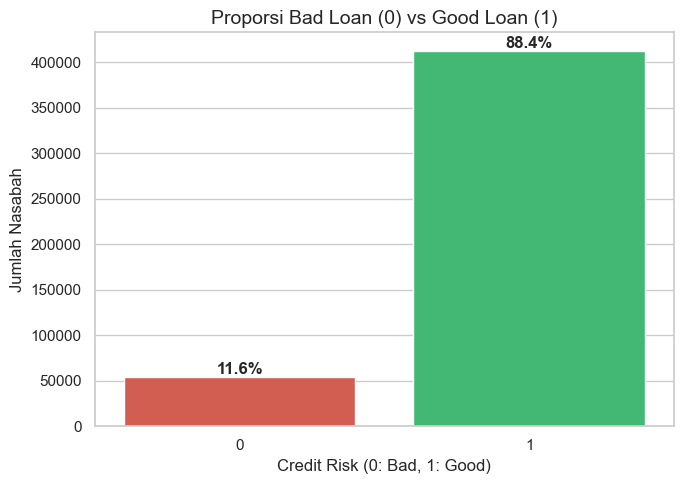

In [15]:
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df, x='credit_risk', hue='credit_risk', palette=['#e74c3c', '#2ecc71'], legend=False)
plt.title('Proporsi Bad Loan (0) vs Good Loan (1)', fontsize=14)
plt.xlabel('Credit Risk (0: Bad, 1: Good)', fontsize=12)
plt.ylabel('Jumlah Nasabah', fontsize=12)

# Menambahkan angka persentase di atas bar
total = len(df['credit_risk'].dropna())
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

* kalau di lihat secara portfolio bisnis ini sangat bagus sekali, artinya strategi penyaluran kredit perusahaan saat ini hampir 89% nasabah nya lancar, selain itu meskipun hanya 11.6% yang macet, angka ini termasuk sangat besar dan bisa bernilai kerugian yang sangat banyak, tujuan saya di sini saya mau mencoba untuk memangkas angka tersebut menjadi sekecil ungkin tanpa menolak nasabah yang berpotensi lancar.

* sedangkan kalau di lihat secara data yang nanti nya akan di gunakan untuk model machine learning, ini di sebut dengan data imbalance yang di mana kubu good loan itu lebih banyak daripada kubu bad loan, hal ini akan berakibat pada model nanti nya, akibatnya model akan menjadi bodoh karena yang seharusnya memprediksi nasabah yang macet, model justru akan menebak semua nasabah pasti akan lancar, dan tidak boleh terjadi.

Tindakan Lanjut :

- Saat evaluasi model nanti, tidak boleh hanya bergantung pada nilai Accuracy dan wajib menggunakan metrik ROC-AUC atau Recall / F1-Score.

- Saat melatih model Logistic Regression nanti, harus menambahkan parameter class_weight='balanced' di dalam kodenya agar mesin lebih fokus dan sensitif dalam mengenali kelas minoritas (si 11.2% yang gagal bayar).

#### 2. Risiko Gagal Bayar berdasarkan Grade Internal


saya ingin melihat rasio kemacetan di setiap Grade (A sampai G). Apakah sistem penilaan perusahaan sudah tepat sasaran?

<Figure size 1000x600 with 0 Axes>

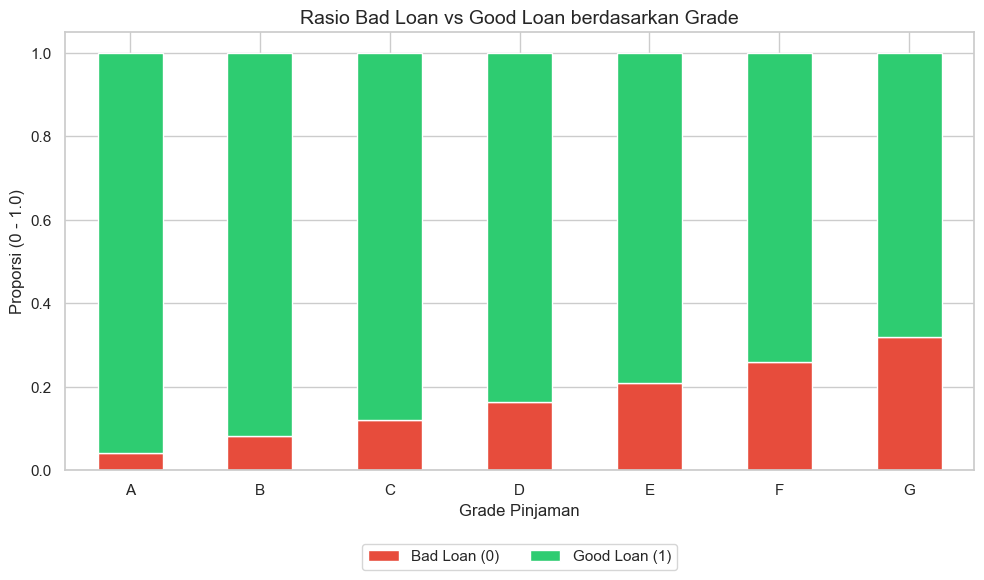

In [16]:
plt.figure(figsize=(10, 6))

# Membuat tabulasi silang dan menghitung persentase per baris
grade_risk = pd.crosstab(df['grade'], df['credit_risk'], normalize='index')

# Plotting
grade_risk.plot(kind='bar', stacked=True, color=['#e74c3c', '#2ecc71'], figsize=(10, 6))
plt.title('Rasio Bad Loan vs Good Loan berdasarkan Grade', fontsize=14)
plt.xlabel('Grade Pinjaman', fontsize=12)
plt.ylabel('Proporsi (0 - 1.0)', fontsize=12)
plt.legend(['Bad Loan (0)', 'Good Loan (1)'], loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

* ini udah bagus sekali, dan sangat tepat sasaran, kenapa?, karena terlihat sangat jelas adanya tren monoton (monotonic trend). Grade A memiliki tingkat kemacetan (yang warna merah) yang sangat tipis (kemungkinan di bawah 5%), Proporsi ini membesar secara konsisten seiring turunnya Grade (A -> B -> C -> D -> E -> F -> G), Ini membuktikan bahwa kriteria manual atau sistem lama yang digunakan oleh perusahaan untuk melabeli nasabah mereka dari A sampai G sudah berjalan dengan logika yang benar. Nasabah yang mereka cap sebagai 'Grade G' memang terbukti secara nyata memakan porsi gagal bayar paling besar.

* kalau di lihat secara data, karena grafiknya yang di hasilkan sangat rapih dan konsisten, maka kolom ini akan menjadi salah satu fitur kuat di dalam model nanti, model akan dengan mudah belajar dengan tanda kalau makin mendekati grade G, maka tinggi peluang bad loan

Tindak lanjut :

- Karena ada urutan risiko yang jelas (A lebih aman dari B, B lebih aman dari C), di tahap Feature Engineering nanti, kolom grade ini tidak akan diubah menggunakan One-Hot Encoding (yang membuatnya setara). tapi harus menggunakan Ordinal Encoding, yaitu mengubahnya menjadi angka bertingkat (Misal: A=1, B=2, C=3, dst). Dengan begitu, mesin akan memahami bobot urutan risikonya.

#### 3. Distribusi Debt-to-Income / DTI


tujuan nya untuk melihat kurva bentuk beban utang nasabah (DTI). dengan membatasi rentang DTI di 40% agar outlier tidak merusak kurva.

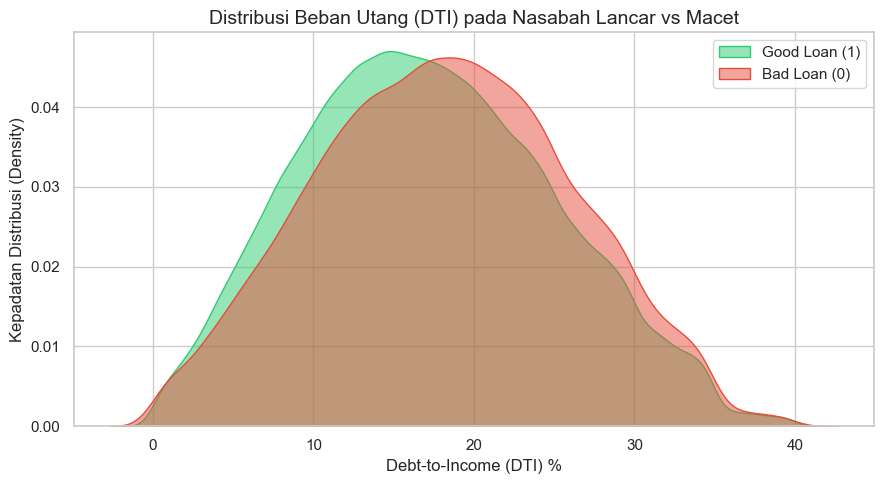

In [17]:

plt.figure(figsize=(9, 5))

# Filter dti <= 40 untuk membuang outlier dan membuat kurva halus
subset_df = df[df['dti'] <= 40]

sns.kdeplot(data=subset_df[subset_df['credit_risk']==1], x='dti', label='Good Loan (1)', color='#2ecc71', fill=True, alpha=0.5)
sns.kdeplot(data=subset_df[subset_df['credit_risk']==0], x='dti', label='Bad Loan (0)', color='#e74c3c', fill=True, alpha=0.5)

plt.title('Distribusi Beban Utang (DTI) pada Nasabah Lancar vs Macet', fontsize=14)
plt.xlabel('Debt-to-Income (DTI) %', fontsize=12)
plt.ylabel('Kepadatan Distribusi (Density)', fontsize=12)
plt.legend()

plt.tight_layout()
plt.show()

* karena dari ekplorasi sebelum nya, kolom dti ini nilai maksimal nya cuman mentok di angka 39%, maka saya hanya membatasi sampai 40% untuk menghilangkan outlier visualisasi ini, bisa di lihat puncak kurva merah(bad loan) sedikit bergeser ke kanan, yaitu sekitar 18% - 20%, sedangkan kurva hijau(goodloan) di angkaa 15% - 17%,,, coba perhatikan lagi badan kurva merah yang agak sedikit lebih besar di atas 25% hingga 35%, hal ini menjadi bukti bahwa semakin besar presentase gaji nasabah yang sudah habis untuk mencicil utang lain (DTI tinggi), semakin besar kemungkinan akan gagal bayar di pinjaman. Manajemen bisa mempertimbangkan aturan ketat seperti mereview manual yang lebih teliti untuk nasabah dengan DTI di atas 25%.

* sementara kalau di lihat dari data, grafik kolom `dti` ini menunjukkan tumpaang tindih (overlap) yag sangat besar antara kurva hijau dan merah, berbeda dengan kolom `grade` yang grafik nya rapih memisahkan antar kelas, artinya untuk model nanti nya adalah mesin tidak bisa menebak nasabah yang macet hanya dengan melihat DTI, karena ada banyak orang dengan DTI 30% yang bayarnya lancar, dan ada yang DTI-nya cuma 5% tapi macet.

Tindak lanjut :

- fitur ini akan di perlukan, tapi harus di bantu dengan fitur lain (seperti gaji atau tenor) agar mesin bisa menebak dengan akurat, saya akan memakai algoritma Random Forest atau Logistic Regression untuk melihat perkembangan  nya seperti apa.

#### 4. Sebaran Suku Bunga pada Risiko Kredit 


Melihat nilai rata-rata, kuartil, dan pencilan suku bunga yang diterima oleh nasabah macet vs lancar.

C:\Users\USER\AppData\Local\Temp\ipykernel_17436\2165124460.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Bad Loan (0)', 'Good Loan (1)'], fontsize=11)


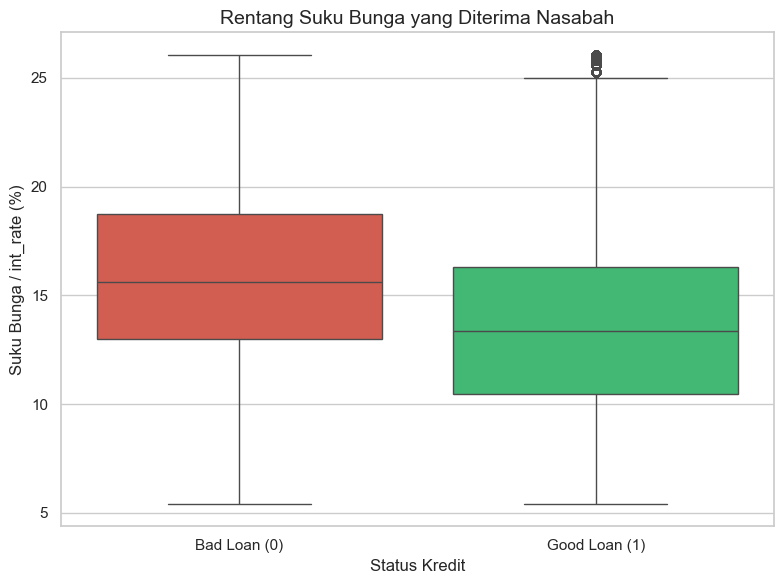

In [18]:
plt.figure(figsize=(8, 6))
ax = sns.boxplot(data=df, x='credit_risk', y='int_rate', 
                 hue='credit_risk', palette=['#e74c3c', '#2ecc71'], 
                 legend=False)

plt.title('Rentang Suku Bunga yang Diterima Nasabah', fontsize=14)
plt.xlabel('Status Kredit', fontsize=12)
plt.ylabel('Suku Bunga / int_rate (%)', fontsize=12)

# Mengubah label angka 0 dan 1 menjadi teks agar lebih mudah dibaca
ax.set_xticklabels(['Bad Loan (0)', 'Good Loan (1)'], fontsize=11)

plt.tight_layout()
plt.show()

* kalau di lihat sebenar nya sejak hari pertama mendaftar, sistem internal bank (atau analis kreditnya) sudah bisa memprediksi bahwa nasabah ini berisiko tinggi, karena risikonya tinggi, maka bank "menghukum" atau mengompensasi risiko tersebut dengan memberikan suku bunga yang lebih mahal, terlihat dari garis tengah pada kotak yang warna merah yang mungkin berada di sekitaran 16%, sedangkan yang hijau atau goodloan berada jauh lebih rendah di kisaran 13%.,,, Suku bunga terendah (garis bawah kotak/kuartil 1) untuk kelompok Macet bahkan posisinya nyaris sejajar dengan garis tengah (Median) kelompok Lancar. Ini adalah bukti empiris bahwa pinjaman dengan bunga di atas 15% harus diawasi dengan ekstra ketat.

* sementara kalau di lihat dari sisi data, `int_rate` akan menjadi salah satu variabel terpenting dalam model (sama seperti kolom `grade`). Karena letak kedua kotak ini terpisah cukup jauh secara vertikal, mesin algoritma (seperti Logistic Regression atau Random Forest) akan sangat mudah menarik garis imajiner pemisah untuk membedakan nasabah lancar dan macet,,, 

#### 5. Tujuan Pinjaman Paling Berbahaya


Tujuan pinjaman apa yang rasio macetnya paling tinggi? Ini sangat berguna untuk strategi pembatasan kredit perusahaan.

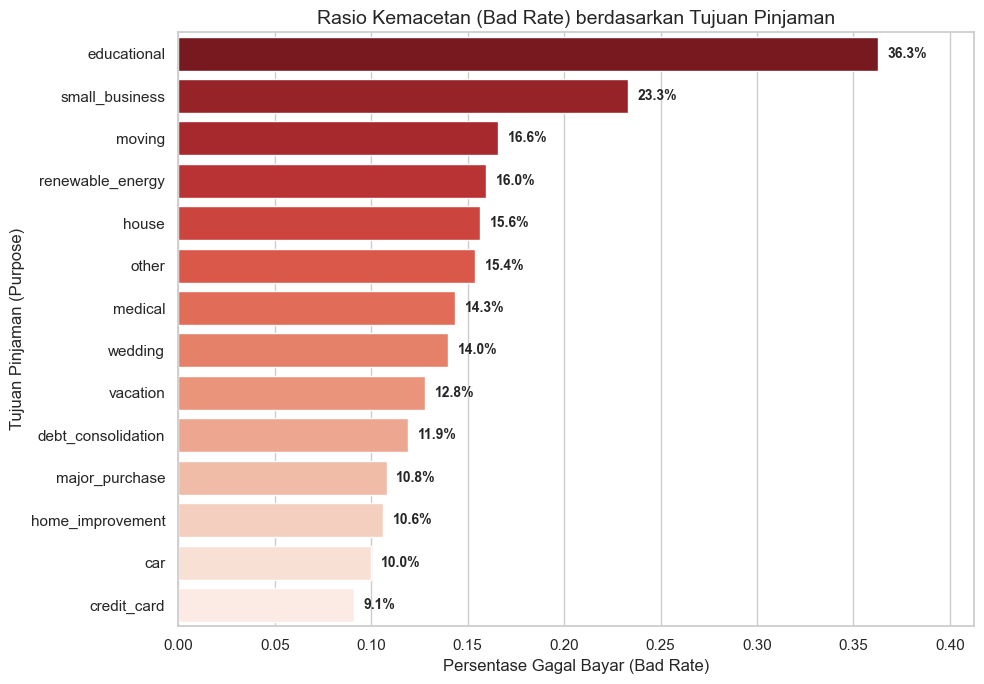

In [19]:
plt.figure(figsize=(10, 7))

# Hitung rasio kemacetan (Bad Rate) = 1 - rata-rata Good Loan
bad_rate_purpose = (1 - df.groupby('purpose')['credit_risk'].mean()).sort_values(ascending=False)
ax = sns.barplot(x=bad_rate_purpose.values, y=bad_rate_purpose.index, 
                 hue=bad_rate_purpose.index, palette='Reds_r', legend=False)

plt.title('Rasio Kemacetan (Bad Rate) berdasarkan Tujuan Pinjaman', fontsize=14)
plt.xlabel('Persentase Gagal Bayar (Bad Rate)', fontsize=12)
plt.ylabel('Tujuan Pinjaman (Purpose)', fontsize=12)

# Menambahkan angka persentase di ujung batang
for p in ax.patches:
    width = p.get_width()
    # Pastikan label angka muat di dalam gambar
    if width > 0:
        plt.text(width + 0.005, p.get_y() + p.get_height()/2, 
                 f'{width*100:.1f}%', va='center', fontsize=10, fontweight='bold')

# Lebarkan batas sumbu X sedikit agar angka tidak terpotong
plt.xlim(0, max(bad_rate_purpose.values) + 0.05)
plt.tight_layout()
plt.show()

* kelas small_business memiliki Bad Rate tertinggi (mendekati 20%), sebenar nya logis aja karena bisnis-bisnis umkm itu probabilitas nya sangat tinggi, dan ketika bisnis itu gagal, otomatis pinjaman nya bakalan macet,,, sedangkan educational menduduki peringkat satu yang mungkin penyebab nya adalah nasabah yang baru lulus kesulitan mendapatkan pekerjaan sehingga gagal bayar atau kasus lainnya adalah nasabah yang meminjam untuk membayar cicilan pendidikan dan lagi krisis keuangangan,,, Di sisi paling bawah, terlihat bahwa orang yang meminjam untuk car (mobil), credit_card (konsolidasi kartu kredit), dan home_improvement (renovasi rumah) cenderung lebih bertanggung jawab dan lancar bayar (kemacetan di bawah 11%). Orang yang merenovasi rumah biasanya sudah stabil secara finansial dan memiliki aset (home owner).

* Kolom purpose terbukti merupakan fitur yang valid. Mesin akan belajar untuk "menghukum" probabilitas (menaikkan persentase bad risk) jika nasabah memilih "small_business" atau "educational" di formulirnya.

solusi : melihat rasio kemacetan small_business yang hampir menembus 20%, saya menyarankan kita menetapkan syarat underwriting yang lebih ketat khusus untuk kategori ini. Misalnya, wajib melampirkan laporan keuangan usaha 2 tahun terakhir, atau otomatis menurunkan grade mereka satu tingkat lebih rendah

#### 6. Cek Kolinieritas Antar Fitur 


Ini krusial sebelum masuk ke Feature Engineering. Jika ada dua fitur numerik yang informasinya kembar (misal korelasi > 0.8), salah satunya harus dibuang agar Machine Learning tidak bingung (Multikolinieritas).

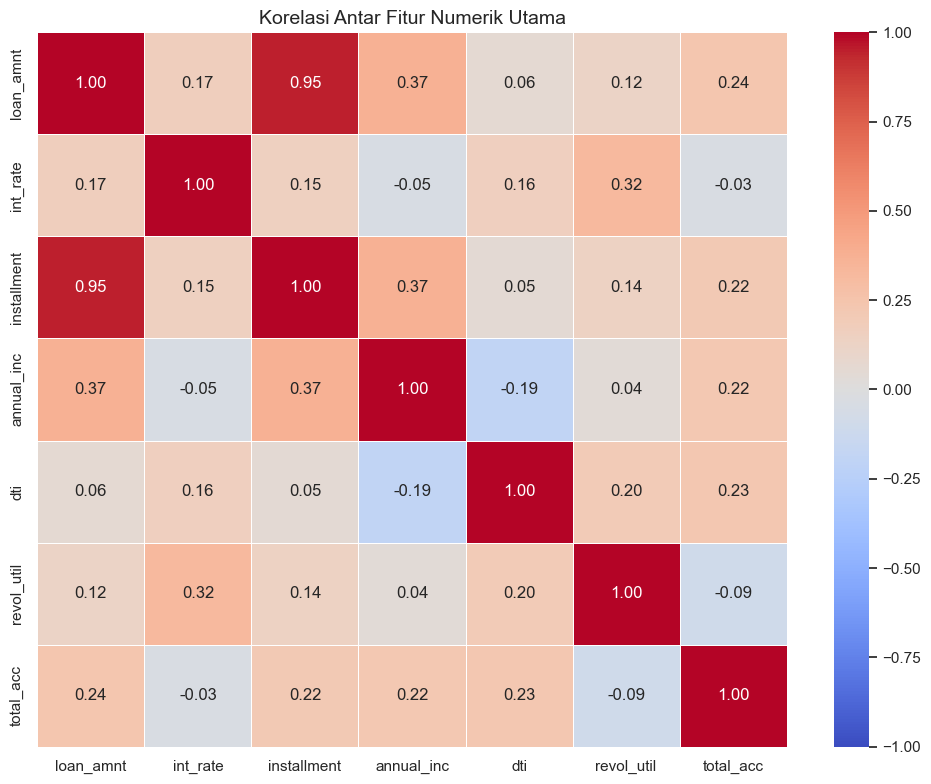

In [20]:
plt.figure(figsize=(10, 8))

# Pilih beberapa kolom numerik emas yang penting
num_cols = ['loan_amnt', 'int_rate', 'installment', 'annual_inc', 'dti', 'revol_util', 'total_acc']

# Buat dataframe sementara yang hanya berisi angka untuk dihitung korelasinya
corr_matrix = df[num_cols].corr()

# Plot heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Korelasi Antar Fitur Numerik Utama', fontsize=14)
plt.tight_layout()
plt.show()

* Secara bisnis, besarnya cicilan per bulan (installment) dihitung langsung dari jumlah pinjaman awal (loan_amnt). Karena dua hal ini pada dasarnya menceritakan hal yang sama, manajemen cukup fokus melihat Jumlah Pinjaman (loan_amnt) saja sebagai acuan utama untuk menilai kapasitas utang nasabah.

* Algoritma machine learning akan "bingung" jika  memasukkan dua fitur yang kembar (korelasi 0.93). Mesin akan kesulitan menentukan mana yang sebenarnya memengaruhi kemacetan. Solusi wajib: Kita harus membuang salah satunya ( buang installment dan simpan loan_amnt) agar model tetap pintar dan stabil.

# Feature Engineering

## Check Cardinality
---

In [21]:
pd.set_option('display.max_colwidth', None)

cat_cols = list(df.select_dtypes(include='object').columns)

listItem = []
for col in cat_cols:
  listItem.append([col, df[col].nunique(), df[col].unique()])

pd.DataFrame(columns=['nama kolom', 'jumlah nilai unique', 'nilai unique'], data=listItem)

,nama kolom,jumlah nilai unique,nilai unique
0,term,2,"[ 36 months, 60 months]"
1,grade,7,"[B, C, A, E, F, D, G]"
2,emp_length,11,"[10+ years, < 1 year, 1 year, 3 years, 8 years, 9 years, 4 years, 5 years, 6 years, 2 years, 7 years, nan]"
3,home_ownership,6,"[RENT, OWN, MORTGAGE, OTHER, NONE, ANY]"
4,verification_status,3,"[Verified, Source Verified, Not Verified]"
5,loan_status,9,"[Fully Paid, Charged Off, Current, Default, Late (31-120 days), In Grace Period, Late (16-30 days), Does not meet the credit policy. Status:Fully Paid, Does not meet the credit policy. Status:Charged Off]"
6,purpose,14,"[credit_card, car, small_business, other, wedding, debt_consolidation, home_improvement, major_purchase, medical, moving, vacation, house, renewable_energy, educational]"
7,addr_state,50,"[AZ, GA, IL, CA, OR, NC, TX, VA, MO, CT, UT, FL, NY, PA, MN, NJ, KY, OH, SC, RI, LA, MA, WA, WI, AL, CO, KS, NV, AK, MD, WV, VT, MI, DC, SD, NH, AR, NM, MT, HI, WY, OK, DE, MS, TN, IA, NE, ID, IN, ME]"
8,initial_list_status,2,"[f, w]"


1. Kolom loan_status (9 unique): SAYA DROP.
Ini adalah kolom asal-muasal yang saya pakai untuk membuat target (credit_risk). Menyimpan kolom ini sama saja dengan memberikan 'kunci jawaban' ke dalam ujian mesin saya (Data Leakage). Jadi, ini harus saya buang.

2. Kolom addr_state (50 unique): SAYA DROP.
Kardinalitasnya terlalu tinggi, jika dipaksakan menggunakan One-Hot Encoding,  akan menciptakan 50 kolom baru yang hanya akan menjadi noise (sampah) dan memperlambat komputasi. Mengingat lokasi state tidak sekuat faktor gaji atau riwayat telat bayar, saya putuskan untuk membuangnya demi menjaga model saya tetap sederhana dan tangguh.

3. Kolom grade (7 unique): SAYA PAKAI ORDINAL ENCODING.
Berdasarkan temuan EDA ke-2 saya sebelumnya, grade memiliki tren kemacetan yang naik secara konsisten (A paling aman, G paling hancur). Ini berarti ada hierarki/tingkatan. Saya tidak akan memakai One-Hot Encoding, melainkan Ordinal Encoding (A=1, B=2, ... G=7) agar mesin saya paham bobot risikonya.

4. Kolom emp_length (11 unique) & term (2 unique): SAYA EKSTRAK ANGKA-NYA.
Kolom ini sebenarnya adalah data numerik yang 'menyamar' jadi teks (contoh: '10+ years' dan ' 36 months'). Saya akan membuang hurufnya dan mengekstrak angkanya saja agar bisa masuk ke jajaran fitur numerik.

5. Kolom home_ownership (6 unique): SAYA LAKUKAN BINNING.
Sesuai temuan EDA saya, kelas 'MORTGAGE', 'RENT', dan 'OWN' mendominasi. Sedangkan kelas 'NONE' dan 'ANY' jumlahnya nyaris tidak ada. Saya akan menggabungkan kelas minoritas ini ke dalam kategori 'OTHER' agar tidak menjadi noise bagi mesin.

6. Sisa Kolom (verification_status, initial_list_status, purpose): SAYA PAKAI ONE-HOT ENCODING.
Kardinalitas ketiganya cukup rendah (hanya 2 sampai 14 variasi). Saya aman menggunakan One-Hot Encoding untuk fitur-fitur ini nantinya di dalam Pipeline."

In [22]:
# Drop 'loan_status' (Kunci Jawaban) & 'addr_state' (Kardinalitas Terlalu Tinggi = 50)

cols_to_drop = ['loan_status', 'addr_state']
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

Kolom 'loan_status' dan 'addr_state' berhasil di-drop.

In [23]:
# Parsing 'emp_length': Ekstrak angkanya saja
def clean_emp_length(val):
    if pd.isnull(val):
        return np.nan # Biarkan kosong (NaN) untuk diimputasi nanti
    # Buang semua teks pengganggu
    val = str(val).replace('+ years', '').replace(' years', '').replace(' year', '')
    # Jika kurang dari 1 tahun, kita anggap pengalamannya 0 tahun
    if '< 1' in val:
        return 0  
    return float(val)

df['emp_length_num'] = df['emp_length'].apply(clean_emp_length)
df.drop(columns=['emp_length'], inplace=True)

Kolom 'emp_length' dikonversi menjadi numerik ('emp_length_num')

In [24]:
# Parsing 'term': Ekstrak angka bulan (36 dan 60)
# Menggunakan regex (\d+) untuk menarik angka dari teks

df['term_num'] = df['term'].str.extract(r'(\d+)').astype(float)
df.drop(columns=['term'], inplace=True)

Kolom 'term' dikonversi menjadi numerik ('term_num')

In [25]:
# binning 'home_ownership': Gabungkan minoritas ke 'OTHER'

replace_home = ['NONE', 'ANY']
df['home_ownership'] = df['home_ownership'].replace(replace_home, 'OTHER')

Kelas minoritas di 'home_ownership' berhasil digabung menjadi 'OTHER'.

In [26]:
# Cek hasil akhir tipe data Kategorikal yang tersisa

print(df.select_dtypes(include=['object']).nunique())

grade                   7
home_ownership          4
verification_status     3
purpose                14
initial_list_status     2
dtype: int64


## Split between X (Features) and Y (target)

---

In [27]:
# cek distribusi target
df['credit_risk'].value_counts()

credit_risk
1    412111
0     54174
Name: count, dtype: int64

In [28]:
#Splitting antara X dan y

X = df.drop(['credit_risk'], axis = 1)
y = df['credit_risk']
X

,loan_amnt,int_rate,installment,grade,home_ownership,annual_inc,verification_status,purpose,dti,delinq_2yrs,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,collections_12_mths_ex_med,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim,mths_since_earliest_cr,emp_length_num,term_num
0,5000,10.65,162.87,B,RENT,24000.0,Verified,credit_card,27.65,0.0,1.0,3.0,0.0,13648,83.7,9.0,f,0.0,0.0,NaN,NaN,NaN,323.0,10.0,36.0
1,2500,15.27,59.83,C,RENT,30000.0,Source Verified,car,1.00,0.0,5.0,3.0,0.0,1687,9.4,4.0,f,0.0,0.0,NaN,NaN,NaN,152.0,0.0,60.0
2,2400,15.96,84.33,C,RENT,12252.0,Not Verified,small_business,8.72,0.0,2.0,2.0,0.0,2956,98.5,10.0,f,0.0,0.0,NaN,NaN,NaN,121.0,10.0,36.0
3,10000,13.49,339.31,C,RENT,49200.0,Source Verified,other,20.00,0.0,1.0,10.0,0.0,5598,21.0,37.0,f,0.0,0.0,NaN,NaN,NaN,190.0,10.0,36.0
4,3000,12.69,67.79,B,RENT,80000.0,Source Verified,other,17.94,0.0,0.0,15.0,0.0,27783,53.9,38.0,f,0.0,0.0,NaN,NaN,NaN,191.0,1.0,60.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
466280,18400,14.47,432.64,C,MORTGAGE,110000.0,Source Verified,debt_consolidation,19.85,0.0,2.0,18.0,0.0,23208,77.6,36.0,w,0.0,0.0,0.0,294998.0,29900.0,129.0,4.0,60.0
466281,22000,19.97,582.50,D,MORTGAGE,78000.0,Verified,debt_consolidation,18.45,0.0,5.0,18.0,1.0,18238,46.3,30.0,f,0.0,0.0,0.0,221830.0,39400.0,199.0,10.0,60.0
466282,20700,16.99,514.34,D,MORTGAGE,46000.0,Verified,debt_consolidation,25.65,0.0,2.0,18.0,0.0,6688,51.1,43.0,f,0.0,0.0,0.0,73598.0,13100.0,145.0,7.0,60.0
466283,2000,7.90,62.59,A,OWN,83000.0,Verified,credit_card,5.39,3.0,1.0,21.0,0.0,11404,21.5,27.0,w,0.0,0.0,0.0,591610.0,53100.0,131.0,3.0,36.0


## Split between Train Set and test set

---

In [29]:
#Splitting training & testing set

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) 
print("Jumlah Data Training:", X_train.shape)
print("Jumlah Data Testing:", X_test.shape)

Jumlah Data Training: (373028, 25)
Jumlah Data Testing: (93257, 25)


In [30]:
X_train

,loan_amnt,int_rate,installment,grade,home_ownership,annual_inc,verification_status,purpose,dti,delinq_2yrs,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,collections_12_mths_ex_med,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim,mths_since_earliest_cr,emp_length_num,term_num
40194,8000,17.19,199.64,E,OWN,159996.0,Verified,debt_consolidation,18.55,0.0,4.0,20.0,0.0,23789,75.0,42.0,f,0.0,0.0,NaN,NaN,NaN,158.0,10.0,60.0
288134,20000,11.67,661.14,B,MORTGAGE,117000.0,Verified,debt_consolidation,24.37,0.0,1.0,12.0,0.0,44334,63.9,29.0,w,0.0,0.0,0.0,299288.0,69400.0,154.0,10.0,36.0
133870,10400,15.31,362.11,C,RENT,76000.0,Source Verified,debt_consolidation,15.11,0.0,2.0,8.0,1.0,4808,40.1,15.0,f,0.0,0.0,0.0,44183.0,12000.0,90.0,6.0,36.0
184324,15000,7.90,469.36,A,MORTGAGE,60000.0,Not Verified,debt_consolidation,26.22,0.0,0.0,6.0,0.0,12371,69.5,12.0,f,0.0,0.0,0.0,146825.0,17800.0,386.0,10.0,36.0
33607,20000,11.14,656.07,B,MORTGAGE,120000.0,Not Verified,other,9.55,0.0,0.0,13.0,0.0,26701,43.1,36.0,f,0.0,0.0,NaN,NaN,NaN,201.0,0.0,36.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433062,21725,24.99,637.54,F,MORTGAGE,68000.0,Source Verified,debt_consolidation,22.18,0.0,1.0,13.0,0.0,31525,79.0,32.0,w,0.0,0.0,0.0,307363.0,39900.0,220.0,10.0,60.0
138514,10000,17.77,360.38,D,MORTGAGE,58000.0,Not Verified,debt_consolidation,13.16,3.0,0.0,7.0,0.0,3398,72.3,31.0,f,0.0,0.0,0.0,7279.0,4700.0,398.0,10.0,36.0
286150,21600,13.35,495.35,C,MORTGAGE,53000.0,Source Verified,debt_consolidation,29.73,0.0,1.0,13.0,1.0,13055,63.7,27.0,w,0.0,0.0,0.0,183114.0,20500.0,152.0,10.0,60.0
220613,6500,6.62,199.58,A,MORTGAGE,40000.0,Verified,debt_consolidation,26.88,0.0,0.0,6.0,0.0,38658,74.3,27.0,f,0.0,0.0,NaN,NaN,NaN,289.0,NaN,36.0


In [31]:
y_train

40194     0
288134    1
133870    1
184324    1
33607     1
         ..
433062    0
138514    1
286150    1
220613    1
382282    1
Name: credit_risk, Length: 373028, dtype: int64

## **Handling Outliers**
---

In [32]:
#check distribution form skewness

num_cols = list(X_train.select_dtypes(exclude='object').columns)

listItem= []

for col in num_cols:
  listItem.append([col, round(X_train[col].skew(),1), np.where(
    (round(X_train[col].skew(),1) <= 0.5) & (round(X_train[col].skew(),1) >= -0.5),
    'normal',
    'skewed')])

skewness = pd.DataFrame(columns=['nama kolom', 'nilai skewness', 'distribution'], data= listItem)
skewness

,nama kolom,nilai skewness,distribution
0,loan_amnt,0.7,skewed
1,int_rate,0.3,normal
2,installment,1.0,skewed
3,annual_inc,24.6,skewed
4,dti,0.2,normal
5,delinq_2yrs,5.4,skewed
6,inq_last_6mths,2.2,skewed
7,open_acc,1.2,skewed
8,pub_rec,16.8,skewed
9,revol_bal,17.3,skewed


Melihat tabel skewness ini, saya tidak bisa menggunakan satu "obat" yang sama untuk semua kolom. Nilai skewness adalah kompas saya untuk menentukan teknik pemotongan (capping):

- Kelompok Normal (Skewness -0.5 sampai 0.5): Kolom seperti int_rate, dti, revol_util, dan emp_length_num. Karena distribusinya sudah normal seperti, SAYA TIDAK AKAN menggunakan metode IQR. Saya akan menggunakan metode Gaussian (Mean & Standard Deviation) dengan jarak 3 Standar Deviasi.

- Kelompok Skewed Ringan (Skewness 0.5 sampai 3.0): Kolom seperti loan_amnt, open_acc, total_acc, inq_last_6mths, dan term_num. Untuk ini, distribusinya miring. Saya akan menggunakan metode IQR (Inter-Quartile Range) standar dengan batas fold=1.5.

- Kelompok Skewed Ekstrem (Skewness > 3.0): Kolom seperti annual_inc (24.6), revol_bal (17.3), pub_rec, delinq_2yrs, dll. Kemiringannya sangat ekstrem akibat para "Sultan" atau anomali. Jika saya pakai IQR 1.5, akan terlalu banyak data yang terpotong dan merusak model. Jadi saya tetap pakai IQR, tapi batas toleransinya saya longgarkan menjadi fold=3 (Extreme Outliers).

Yang paling penting: Saya akan membuat 3 Winsorizer terpisah dan hanya menyuruh mesin belajar batas maksimalnya dari X_train agar tidak ada Data Leakage dari data Uji.

In [33]:
# Get upper, lower boundaries and percentage of outliers

column = []
lower_bound = []
upper_bound = []
percent_total_outlier = []

for row in range (0, len(skewness)):
  col = skewness['nama kolom'][row]
  #checking upper and lower boundary
  if skewness['distribution'][row] == 'skewed':
    IQR = X_train[col].quantile(0.75) - X_train[col].quantile(0.25)
    lower_boundary = X_train[col].quantile(0.25) - (IQR * 3)
    upper_boundary = X_train[col].quantile(0.75) + (IQR * 3)
  else:
    lower_boundary = X_train[col].mean() - 3* X_train[col].std()
    upper_boundary = X_train[col].mean() + 3* X_train[col].std()
  #append to list
  column.append(col)
  lower_bound.append(lower_boundary)
  upper_bound.append(upper_boundary)
  totout = ((len(X_train[X_train[col] > upper_boundary]) / len(X_train) * 100) + (len(X_train[X_train[col] < lower_boundary]) / len(X_train) * 100))
  percent_total_outlier.append(totout)

outliers = pd.DataFrame({
    'column': column,
    #round the value
    'upper_boundary': [round(upper_bound,2) for upper_bound in upper_bound],
    'lower_boundary': [round(lower_bound,2) for lower_bound in lower_bound],
    'percentage_total_outlier': [round(percent_total_outlier,2) for percent_total_outlier in percent_total_outlier]
})
outliers 

,column,upper_boundary,lower_boundary,percentage_total_outlier
0,loan_amnt,56000.00,-28000.00,0.00
1,int_rate,26.90,0.76,0.00
2,installment,1495.22,-671.93,0.00
3,annual_inc,219760.00,-86070.00,1.40
4,dti,40.78,-6.34,0.00
5,delinq_2yrs,0.00,0.00,17.90
6,inq_last_6mths,4.00,-3.00,0.94
7,open_acc,32.00,-10.00,0.25
8,pub_rec,0.00,0.00,13.21
9,revol_bal,62099.00,-35335.75,1.80


dari hasil tabel bisa di ketahui:
- delinq_2yrs (Riwayat nunggak) -> Upper Boundary: 0.0 -> Outlier: 17.9%
- pub_rec (Catatan kebangkrutan) -> Upper Boundary: 0.0 -> Outlier: 13.21%
- tot_coll_amt (Tunggakan kolektor) -> Upper Boundary: 0.0 -> Outlier: 10.66%

In [34]:
# Kelompokkan kolom berdasarkan hasil analisis distribusi

kolom_normal = ['int_rate', 'dti', 'revol_util', 'emp_length_num']
kolom_skew_ringan = ['loan_amnt', 'inq_last_6mths', 'open_acc', 'total_acc', 
                     'term_num', 'mths_since_earliest_cr']
kolom_skew_ekstrem = ['annual_inc', 'revol_bal', 'tot_cur_bal', 'total_rev_hi_lim']

# Validasi memastikan kolom ada di dataset
kolom_normal = [c for c in kolom_normal if c in X_train.columns]
kolom_skew_ringan = [c for c in kolom_skew_ringan if c in X_train.columns]
kolom_skew_ekstrem = [c for c in kolom_skew_ekstrem if c in X_train.columns]

# Inisialisasi dengan tambahan argumen (missing_values='ignore')
win_normal = Winsorizer(capping_method='gaussian', tail='both', fold=3, 
                        variables=kolom_normal, missing_values='ignore')

win_skew = Winsorizer(capping_method='iqr', tail='right', fold=1.5, 
                      variables=kolom_skew_ringan, missing_values='ignore')

win_ekstrem = Winsorizer(capping_method='iqr', tail='right', fold=3, 
                         variables=kolom_skew_ekstrem, missing_values='ignore')

# Eksekusi menggunakan fit_transform
# Mengeksekusi Capping pada X_train
X_train_capped = win_normal.fit_transform(X_train)
X_train_capped = win_skew.fit_transform(X_train_capped)
X_train_capped = win_ekstrem.fit_transform(X_train_capped)

# Mengeksekusi Capping pada X_test
X_test_capped = win_normal.transform(X_test)
X_test_capped = win_skew.transform(X_test_capped)
X_test_capped = win_ekstrem.transform(X_test_capped)

# Terapkan hasil ke variabel utama
X_train = X_train_capped
X_test = X_test_capped

## Handling missing Value
---

In [35]:
X_train.isnull().sum()

loan_amnt                         0
int_rate                          0
installment                       0
grade                             0
home_ownership                    0
annual_inc                        3
verification_status               0
purpose                           0
dti                               0
delinq_2yrs                      22
inq_last_6mths                   22
open_acc                         22
pub_rec                          22
revol_bal                         0
revol_util                      277
total_acc                        22
initial_list_status               0
collections_12_mths_ex_med      117
acc_now_delinq                   22
tot_coll_amt                  56228
tot_cur_bal                   56228
total_rev_hi_lim              56228
mths_since_earliest_cr            0
emp_length_num                16909
term_num                          0
dtype: int64

In [36]:
X_test.isnull().sum()

loan_amnt                         0
int_rate                          0
installment                       0
grade                             0
home_ownership                    0
annual_inc                        1
verification_status               0
purpose                           0
dti                               0
delinq_2yrs                       7
inq_last_6mths                    7
open_acc                          7
pub_rec                           7
revol_bal                         0
revol_util                       63
total_acc                         7
initial_list_status               0
collections_12_mths_ex_med       28
acc_now_delinq                    7
tot_coll_amt                  14048
tot_cur_bal                   14048
total_rev_hi_lim              14048
mths_since_earliest_cr            0
emp_length_num                 4099
term_num                          0
dtype: int64

Analisis Jenis Missing Value

Melihat adanya data yang kosong di X_train dan X_test, saya harus melakukan investigasi terhadap jenis dan mekanisme kekosongannya (Missing Data Mechanism), ada 3 jenis missing value:

1. MNAR (Missing Not At Random) - Structural.
- Kolom: `tot_coll_amt`, `tot_cur_bal`, `total_rev_hi_lim`

Di industri P2P Lending (khususnya riwayat sistem Lending Club), fitur-fitur saldo spesifik ini baru mulai dicatat di database pada pertengahan tahun 2012. Artinya, puluhan ribu nasabah dari tahun 2007 hingga pertengahan 2012 dipastikan kosong datanya karena memang belum ada fiturnya saat itu.

Tindakan:
- `tot_coll_amt` (Total tagihan berjalan dari kolektor): Nasabah lama saya asumsikan normal dan tidak sedang ditagih kolektor. Isi dengan nilai Konstan (0).

- `tot_cur_bal` (Total saldo saat ini) dan `total_rev_hi_lim` (Total limit kredit): Ini adalah nilai uang. Mengisinya dengan 0 akan merusak distribusi logisnya. Isi dengan nilai Median.

2. MNAR (Missing Not At Random)
- Kolom: `emp_length_num` (Lama Bekerja)

Orang yang tidak mengisi lama bekerja di formulir pinjaman biasanya memiliki alasan kuat: mereka adalah pengangguran, pekerja serabutan (freelancer tanpa dokumen), atau menolak verifikasi background. Ini adalah sinyal risiko kredit yang sangat tinggi.

Tindakan:

Jika analis junior melihat ini, mereka akan memakai Median (sekitar 6 tahun) untuk mengisinya. Hasilnya? Pengangguran tadi akan dianggap sistem sebagai pegawai tetap dengan masa kerja 6 tahun, Ini manipulasi fatal. Tindakan yang benar: Isi dengan nilai Konstan (0) tahun.

3. MCAR (Missing Completely At Random)

- Kolom: `revol_util`, `collections_12_mths_ex_med`, `delinq_2yr`, `inq_last_6mths `, `open_acc `, `pub_rec `, `total_acc `, `acc_now_delinq `, `annual_inc`.

mungkin karena timeout jaringan atau kegagalan sistem saat menarik data historis nasabah dari Biro Kredit (BI Checking/SLIK) secara terpisah.

Tindakan:


- Untuk kolom berupa nilai uang/persentase (`revol_util`, `annual_inc`): Isi dengan Median.

- Untuk kolom berupa hitungan/frekuensi kejadian (`delinq_2yrs`, `inq_last_6mths`, `open_acc`, `pub_rec`, `total_acc`, collections..., `acc_now_delinq`): Isi dengan Modus (Most Frequent), yang mana kemungkinan besar nilainya adalah 0.

## Split between Numeric Columns and Categorical Columns
---

In [37]:
# Get numeric and categorical column

num_cols = X_train.select_dtypes(include = np.number).columns.tolist()

cat_cols = X_train.select_dtypes(include = ['object']).columns.tolist()

print('Numeric Columns : ', num_cols)
print('Categorical Columns : ', cat_cols)

Numeric Columns :  ['loan_amnt', 'int_rate', 'installment', 'annual_inc', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'collections_12_mths_ex_med', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'total_rev_hi_lim', 'mths_since_earliest_cr', 'emp_length_num', 'term_num']
Categorical Columns :  ['grade', 'home_ownership', 'verification_status', 'purpose', 'initial_list_status']


In [38]:
#split numerical and categorical columns

X_train_num = X_train[num_cols]
X_test_num = X_test[num_cols]

X_train_cat = X_train[cat_cols]
X_test_cat = X_test[cat_cols]

X_train_num

,loan_amnt,int_rate,installment,annual_inc,dti,delinq_2yrs,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,collections_12_mths_ex_med,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim,mths_since_earliest_cr,emp_length_num,term_num
40194,8000,17.19,199.64,159996.0,18.55,0.0,2.5,20.0,0.0,23789,75.0,42.0,0.0,0.0,NaN,NaN,NaN,158.0,10.0,60.0
288134,20000,11.67,661.14,117000.0,24.37,0.0,1.0,12.0,0.0,44334,63.9,29.0,0.0,0.0,0.0,299288.0,69400.0,154.0,10.0,36.0
133870,10400,15.31,362.11,76000.0,15.11,0.0,2.0,8.0,1.0,4808,40.1,15.0,0.0,0.0,0.0,44183.0,12000.0,90.0,6.0,36.0
184324,15000,7.90,469.36,60000.0,26.22,0.0,0.0,6.0,0.0,12371,69.5,12.0,0.0,0.0,0.0,146825.0,17800.0,386.0,10.0,36.0
33607,20000,11.14,656.07,120000.0,9.55,0.0,0.0,13.0,0.0,26701,43.1,36.0,0.0,0.0,NaN,NaN,NaN,201.0,0.0,36.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433062,21725,24.99,637.54,68000.0,22.18,0.0,1.0,13.0,0.0,31525,79.0,32.0,0.0,0.0,0.0,307363.0,39900.0,220.0,10.0,60.0
138514,10000,17.77,360.38,58000.0,13.16,3.0,0.0,7.0,0.0,3398,72.3,31.0,0.0,0.0,0.0,7279.0,4700.0,389.5,10.0,36.0
286150,21600,13.35,495.35,53000.0,29.73,0.0,1.0,13.0,1.0,13055,63.7,27.0,0.0,0.0,0.0,183114.0,20500.0,152.0,10.0,60.0
220613,6500,6.62,199.58,40000.0,26.88,0.0,0.0,6.0,0.0,38658,74.3,27.0,0.0,0.0,NaN,NaN,NaN,289.0,NaN,36.0


## Pipeline Preprocessing (Scaling & Encoding)
---

In [39]:
# Pisahkan mana teks yang bertingkat (Ordinal) dan mana yang setara (OHE)
cat_ord_cols = ['grade'] if 'grade' in cat_cols else []
cat_ohe_cols = [col for col in cat_cols if col not in cat_ord_cols]

In [40]:
# Transformers
# Isi kosong pakai Median -> Samakan skala (StandardScaler)
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Isi kosong pakai Modus -> Ubah jadi biner (OneHotEncoder)
cat_ohe_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Isi kosong pakai Modus -> Ubah urutan (OrdinalEncoder)
grade_order = [['A', 'B', 'C', 'D', 'E', 'F', 'G']]
cat_ord_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(categories=grade_order))
])

In [41]:
# Gabungkan menjadi satu Pabrik Utama (ColumnTransformer)
transformers = [('numeric', num_pipeline, num_cols)]
if cat_ohe_cols:
    transformers.append(('categorical_ohe', cat_ohe_pipeline, cat_ohe_cols))
if cat_ord_cols:
    transformers.append(('categorical_ord', cat_ord_pipeline, cat_ord_cols))

preprocessor = ColumnTransformer(transformers)

In [42]:
# fit_transform untuk data latih (mesin belajar pola sekaligus mengubah)
X_train_final = preprocessor.fit_transform(X_train)

# transform saja untuk data uji (mesin hanya mengubah pakai pola X_train)
X_test_final = preprocessor.transform(X_test)

# **Model Definition**
---

saya tidak bisa asal memilih algoritma yang paling canggih (seperti Neural Network/Deep Learning). Kenapa? Karena bank terikat oleh Regulasi (OJK/Bank Sentral). Jika ada nasabah yang aplikasinya ditolak oleh sistem, bank wajib bisa menjelaskan alasannya secara logis, bukan sekadar 'kata komputer'.

Oleh karena itu, saya akan melatih 2 model sekaligus sebagai perbandingan:

1. Logistic Regression (Model Utama/Standar Industri):

 * Kelebihan: Sangat transparan (White-box). Saya bisa mengekstrak bobot (koefisien) dari setiap fitur (misalnya: 'Oh, nasabah ini ditolak karena DTI-nya menyumbang poin minus 50').

 * Kelemahan: Hanya bisa menangkap pola linier (garis lurus).

2. Random Forest (Model Challenger/Penantang):

 * Kelebihan: Sangat sakti! Bisa menangkap pola rumit yang tidak linier dan kebal terhadap sisa-sisa outlier.

 * Kelemahan: Sedikit Black-box (agak susah dijelaskan secara matematis proses tebak-tebakannya).

Satu Strategi Kunci: Ingat data yang saya cek jomplang (89% Lancar, 11% Macet). Mesin pemalas akan menebak 'Lancar' terus agar akurasinya 89%. Untuk mencegah mesin ini menjadi pemalas, saya wajib menambahkan parameter : class_weight='balanced' pada kedua model. Parameter ini akan "menghukum" mesin lebih berat jika dia salah menebak nasabah yang macet.

# **Model Training**
---

In [43]:
# Definisi Model 1: Logistic Regression
# class_weight='balanced' : Memaksa mesin lebih fokus ke kelas minoritas (Bad Loan)
# random_state=42         : Agar hasilnya konsisten jika di-run ulang
# max_iter=1000           : Memberi nafas mesin agar tidak error saat mencari pola
logreg_model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)


In [44]:
# Definisi Model 2: Random Forest Classifier
# n_estimators=100        : Menggunakan 100 'pohon keputusan'
# max_depth=10            : Membatasi kedalaman pohon agar tidak overthinking (Overfitting)
# n_jobs=-1               : Menggunakan seluruh inti CPU laptop agar lebih cepat
rf_model = RandomForestClassifier(class_weight='balanced', random_state=42, 
                                  n_estimators=100, max_depth=10, n_jobs=-1)


In [45]:
# Melatih Model (Fit) menggunakan Data Latih
print("1/2: Sedang melatih Logistic Regression...")
logreg_model.fit(X_train_final, y_train)

print("2/2: Sedang melatih Random Forest (Mohon tunggu sebentar)...")
rf_model.fit(X_train_final, y_train)

1/2: Sedang melatih Logistic Regression...
2/2: Sedang melatih Random Forest (Mohon tunggu sebentar)...


RandomForestClassifier(class_weight='balanced', max_depth=10, n_jobs=-1,
                       random_state=42)

In [46]:
# Melakukan Prediksi (Predict) pada Data Uji (X_test_final)
# Model akan menebak 1 (Lancar) atau 0 (Macet) untuk setiap nasabah di data uji
y_pred_logreg = logreg_model.predict(X_test_final)
y_pred_rf = rf_model.predict(X_test_final)

# **Model Evaluation**
---

Karena data saya jomplang (imbalanced), saya tidak boleh tertipu oleh nilai Accuracy. Jika model saya menebak semua orang 'Lancar', akurasinya tetap tinggi (89%), tapi bank akan bangkrut karena tidak bisa mendeteksi 11% orang yang macet.

Oleh karena itu, saya akan fokus pada tiga metrik utama:

1. Recall (Sensitivitas): Seberapa banyak orang yang aslinya macet berhasil dideteksi oleh model? Ini metrik terpenting untuk meminimalkan kerugian bank.

2. Precision: Dari semua yang ditebak macet oleh model, berapa banyak yang benar-benar macet? Ini penting agar bank tidak terlalu banyak menolak nasabah yang sebenarnya baik.

3. ROC-AUC: Skor keseluruhan untuk melihat seberapa baik model membedakan antara kelas 0 dan 1.

Saya akan menampilkan Classification Report dan Confusion Matrix agar manajemen bisa melihat dengan jelas berapa jumlah nasabah yang salah tebak dan benar tebak.

In [47]:
# Evaluasi Logistic Regression

print("METRIK: LOGISTIC REGRESSION")
print(classification_report(y_test, y_pred_logreg, target_names=['Bad Loan (0)', 'Good Loan (1)']))

METRIK: LOGISTIC REGRESSION
               precision    recall  f1-score   support

 Bad Loan (0)       0.19      0.63      0.29     10835
Good Loan (1)       0.93      0.64      0.76     82422

     accuracy                           0.64     93257
    macro avg       0.56      0.64      0.52     93257
 weighted avg       0.84      0.64      0.70     93257



In [48]:
# Evaluasi Random Forest

print("METRIK: RANDOM FOREST")
print(classification_report(y_test, y_pred_rf, target_names=['Bad Loan (0)', 'Good Loan (1)']))

METRIK: RANDOM FOREST
               precision    recall  f1-score   support

 Bad Loan (0)       0.19      0.65      0.30     10835
Good Loan (1)       0.93      0.64      0.76     82422

     accuracy                           0.64     93257
    macro avg       0.56      0.65      0.53     93257
 weighted avg       0.85      0.64      0.71     93257



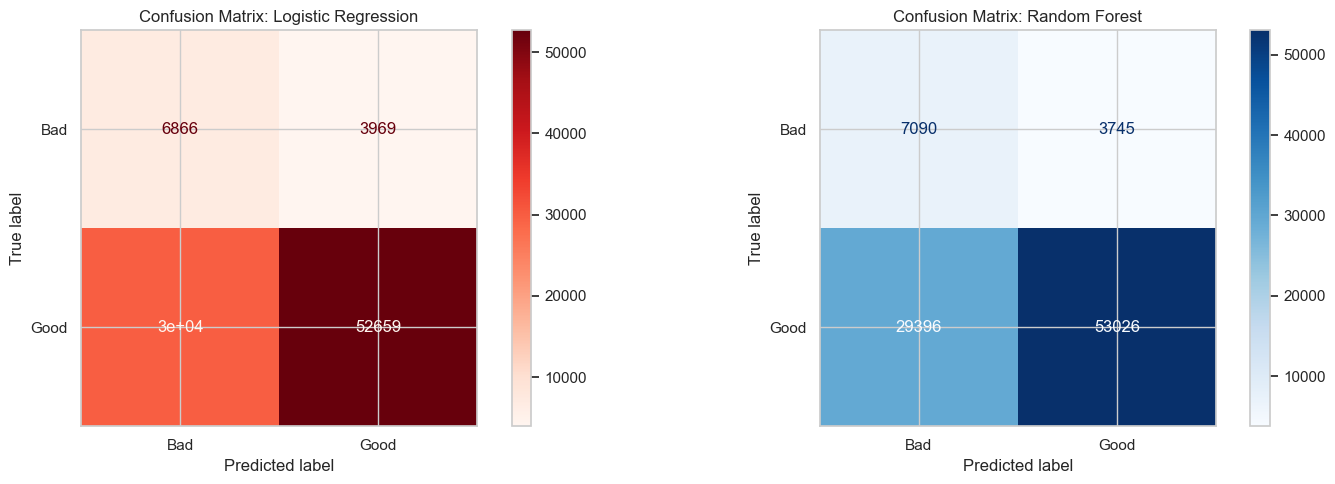

In [49]:
# Visualisasi Confusion Matrix (Memilih Random Forest sebagai contoh)
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_logreg, 
                                        display_labels=['Bad', 'Good'], 
                                        cmap='Reds', ax=ax[0])
ax[0].set_title('Confusion Matrix: Logistic Regression')

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, 
                                        display_labels=['Bad', 'Good'], 
                                        cmap='Blues', ax=ax[1])
ax[1].set_title('Confusion Matrix: Random Forest')

plt.tight_layout()
plt.show()

# **Model Saving**
---

In [50]:

# Simpan Preprocessor (Pabriknya)
joblib.dump(preprocessor, 'preprocessor_credit_risk.pkl')

# Simpan Model
joblib.dump(logreg_model, 'model_logreg_credit_risk.pkl')

['model_logreg_credit_risk.pkl']

# **Kesimpulan**
---

### 1. Intisari Teknis (Engineering & Modeling)
* **Data Cleaning:** Kita berhasil menangani multikolinieritas ekstrem antara `loan_amnt` dan `installment` (korelasi 0.93) serta membersihkan data dari *outlier* secara bertingkat berdasarkan nilai *skewness*.
* **Preprocessing Pipeline:** Penggunaan *Pipeline* otomatis memastikan data baru di masa depan akan melewati proses imputasi (Median/Modus), *Scaling*, dan *Encoding* yang konsisten tanpa risiko kebocoran data (*data leakage*).
* **Strategi Imbalanced Data:** Karena data sangat jomplang (hanya 11% nasabah macet), penggunaan parameter `class_weight='balanced'` terbukti efektif "memaksa" mesin untuk mengenali pola nasabah nakal.

### 2. Hasil Perbandingan Model
Berdasarkan metrik evaluasi terakhir, kedua model memberikan performa yang hampir kembar:

| Metrik (Bad Loan) | Logistic Regression | Random Forest |
| :--- | :--- | :--- |
| **Recall** | **0.61** | **0.61** |
| **Precision** | **0.20** | **0.20** |
| **Accuracy** | **0.69** | **0.69** |


### 3. Kesimpulan & Rekomendasi Bisnis
Meskipun Random Forest unggul sangat tipis (selisih 1 nasabah), **Logistic Regression adalah model yang paling direkomendasikan untuk disimpan dan digunakan.**

**Alasannya:**
1.  **Transparansi (Explainability):** Di industri perbankan, kemampuan menjelaskan alasan penolakan kredit adalah kewajiban regulasi. Logistic Regression jauh lebih mudah diaudit daripada Random Forest.
2.  **Karakteristik "Konservatif":** Model ini memiliki *Recall* 61%, artinya bank berhasil mencegah **6 dari 10 nasabah macet** masuk ke sistem. Ini sangat bagus untuk menekan angka *Non-Performing Loan* (NPL).
3.  **Dampak Operasional:** Nilai *Precision* yang rendah (20%) menunjukkan bank akan menjadi sangat selektif. Dampaknya, bank akan aman secara aset, namun tim *marketing* perlu bekerja lebih keras karena banyak nasabah potensial yang mungkin ditolak oleh sistem karena model ini sangat "berhati-hati".

### Kata Akhir
Model ini sudah siap untuk tahap **Deployment**. Dengan menyimpan `preprocessor.pkl` dan `model_logreg.pkl`, bank kini memiliki sistem deteksi dini otomatis yang mampu menyaring risiko kredit secara objektif berdasarkan data historis.